# Importing Required Libraries

In [35]:
import glob
import librosa
import pandas as pd
import numpy as np
import os
import math
import seaborn as sns
import matplotlib.pyplot as plt

# EDA

In [6]:
DATA_ROOT = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems'# Enter dataset path
GENRES = ["blues", "classical", "country", "disco", "hiphop","jazz", "metal", "pop", "reggae", "rock"] # Make the list of all genres available
STEM_KEYS = ['drums', 'vocals', 'bass', 'other']
GENRE_TO_TEST = 'rock'

In [9]:
def build_dataset(root_dir, val_split=0.17, seed=42):
    # Initialize empty dictionaries
    full_dataset =  {g: {s.replace('.wav', ''): [] for s in STEM_KEYS} for g in GENRES}

    # Helper function to populate dict
    def add_to_dict(target_dict, song_list, stem,genre):
        target_dict[genre][stem].append(song_list)

    corrupted_songs = 0
    less_5mb = 0
    more_5mb = 0
    
    for genre in GENRES:
        path = glob.glob(f"{root_dir}/{genre}")

        
        if path == []:
            print(f"Genre folder doesn't exist for {genre}")
            continue
            
        path_to_stems = glob.glob(f'{path[0]}/*')
        
        for sample in path_to_stems:
            total_stems = glob.glob(f"{sample}/*.wav")
            
            if len(total_stems) != 4:
                print(f"Not all stems found in {sample}")
                print(total_stems)
                
            for stems in total_stems:
                size_in_bytes = os.path.getsize(stems)
                
                if size_in_bytes < (4*1024):
                    print(f"corrupted songs {stem}")
                    corrupted_songs += 1
                    
                if size_in_bytes < (5.0491*1024*1024):
                    less_5mb += 1
                if size_in_bytes > (5.0493*1024*1024 ):
                    more_5mb += 1

                stem = stems.split("/")[-1].replace(".wav","")
                add_to_dict(full_dataset,stems,stem,genre)
        
    print(f'Corrupted songs count: {corrupted_songs+less_5mb}') 
    print(f'songs with size less then 5.0491MB: {less_5mb}') 
    print(f'songs with size more then 5.0493MB: {more_5mb}')

    # now spliting full dataset into test and val datasets
    for genre in GENRES:
        for stem in STEM_KEYS:
            data =  full_dataset[genre][stem]
            full_dataset[genre][stem] = data

    return full_dataset
    
dataset = build_dataset(DATA_ROOT)


Corrupted songs count: 1256
songs with size less then 5.0491MB: 1256
songs with size more then 5.0493MB: 184


In [20]:
stem_time_in_sec = {}
for genre in GENRES:
    for stem in STEM_KEYS:
        for path in dataset[genre][stem]:
            duration = librosa.get_duration(path=path)
            duration = int(duration)
            if str(duration) in stem_time_in_sec:
                stem_time_in_sec[str(duration)] += 1
            else: stem_time_in_sec[str(duration)] = 1
stem_time_in_sec

{'30': 3964, '29': 36}

## So the stems we have for training are close to 30 sec audio 

In [16]:
noise_duration = {}
noise = glob.glob("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/*.wav")
for path in noise:
    duration = librosa.get_duration(path=path)
    if str(duration) in noise_duration:
         noise_duration[str(duration)] += 1
    else:  noise_duration[str(duration)] = 1
noise_duration

{'5.0': 2000}

## Noise data have all audio files of 5 sec

<Axes: >

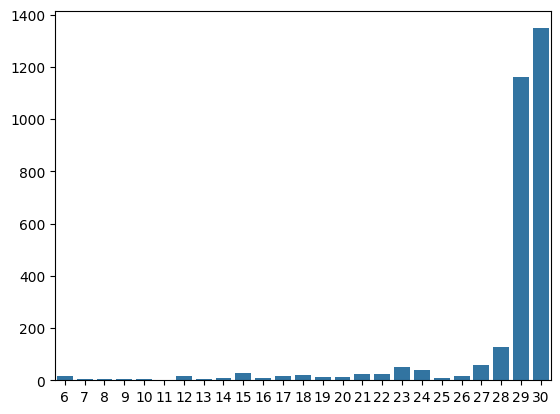

In [29]:
Test_duration = {}
test_audio = glob.glob("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/mashups/*.wav")
for path in test_audio:
    duration = librosa.get_duration(path=path)
    duration = int(duration)
    if str(duration) in Test_duration:
         Test_duration[str(duration)] += 1
    else:  Test_duration[str(duration)] = 1

Test_duration = dict(sorted(Test_duration.items(), key= lambda x: int(x[0])))
sns.barplot(x=Test_duration.keys() , y=Test_duration.values())

## for test data the audio samples are in the range of 6 to 30 sec

In [34]:
def find_long_silences(dataset_dict, sr=22050, threshold_sec=5, top_db=20):
    TOP_DB=20
    """
    Input:
        dataset_dict: The dictionary structure {genre: {stem: [paths...]}}
    Output:
        df: Pandas DataFrame containing details of all files with silence >= 5s
    """
    records = []


    total_files = 0     # ---- COUNT TOTAL FILES ----
    for genre in GENRES:
        for stem in STEM_KEYS:
            files = dataset_dict[genre][stem]
            for sample in files:
                # Load Audio
                audio, _  = librosa.load(sample , sr=sr) 
                non_silent = librosa.effects.split(audio, top_db=TOP_DB)
                silence_type = []
                max_silence = 0
                total_silence = 0

                if len(non_silent) == 0:    # CASE A: Fully silent
                    max_silence = len(audio)/sr
                    total_silence = len(audio)/sr
                    silence_type.append("Fully silent")
                    
                else:
                    if (non_silent[0][0] != 0) and (non_silent[0][0]/sr > threshold_sec ) :   # CASE B: START silence
                        if non_silent[0][0]/sr > max_silence:
                            max_silence = non_silent[0][0]/sr
                        total_silence+= non_silent[0][0]/sr
                        silence_type.append("START silence")

                    if (non_silent[-1][-1] != sr*len(audio)) and ((len(audio)-non_silent[-1][-1])/sr >= threshold_sec ) :   # CASE C: END silence
                        if (len(audio)-non_silent[-1][-1])/sr > max_silence:
                            max_silence = (len(audio)-non_silent[-1][-1])/sr
                        total_silence+= (len(audio)-non_silent[-1][-1])/sr
                        silence_type.append("END silence")

                    i = 0
                    j = 1
                    while j < len(non_silent):
                        gap = non_silent[j][0] - non_silent[i][-1]
                        if gap/sr >= threshold_sec:
                            silence_type.append("MIDDLE silence")
                            if gap/sr > max_silence:
                                max_silence = gap/sr 
                            total_silence += gap/sr
                        i+= 1
                        j+= 1

                if silence_type:
                    records.append({
                    "Genre": genre,
                    "Stem": stem,
                    "Duration": round(total_silence, 2),
                    "Max_Silence_Sec": round(max_silence, 2),
                    "Silence_Location": ", ".join(silence_type),
                    "File_Path": sample
                    })
                    
    df = pd.DataFrame(records)
    return df



df_silence = find_long_silences(dataset, threshold_sec=5, top_db=20)

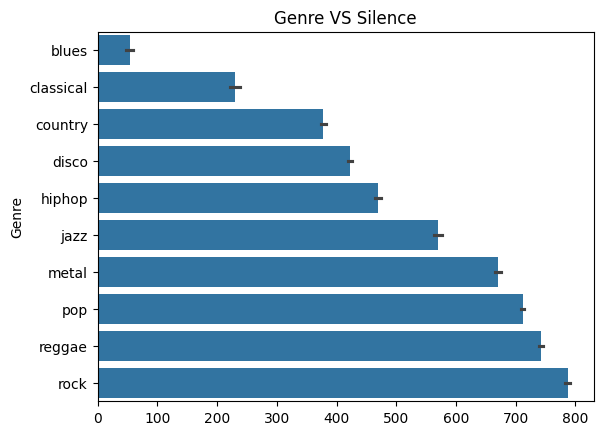

In [36]:
sns.barplot(df_silence["Genre"])
plt.title("Genre VS Silence")
plt.show()

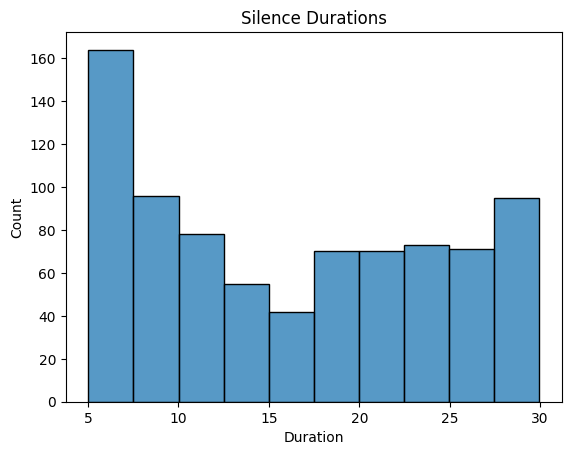

In [37]:
sns.histplot(df_silence["Duration"] , bins = 10 )
plt.title("Silence Durations")
plt.show()

In [39]:
most_silent_file = df_silence.sort_values(by='Duration' , ascending=False).File_Path[0]
audio , _ = librosa.load(most_silent_file, sr=22050)

import IPython.display as ipd
ipd.display(ipd.Audio(audio , rate=22050))
# displaying the most silent audio stem in out train data

In [40]:
"""

So now we know the audio size for test, noise and stem data.
noise has 2000 audio samples and all of those samples are 5sec each 
train data / data stems have total 400 files per genre and most of those files are 30sec each.
test data has variable audio sizes ranging from 6sec to 30sec.

"""

'\nSo now we know the audio size for test, noise and stem data.\nnoise has 2000 audio samples and all of those samples are 5sec each \ntrain data / data stems have total 400 files per genre and most of those files are 30sec each.\ntest data has variable audio sizes ranging from 6sec to 30sec.\n'